In [3]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

In [4]:
data_path = "dataset/"
files = {}
for f in os.listdir(data_path):
    name = f.replace(".csv", "")
    files[name] = pd.read_csv(data_path + f)
    print(f"{f}: {files[name].shape}")

customers.csv: (121930, 7)
geography.csv: (39948, 4)
inventory.csv: (60247, 17)
orders.csv: (646945, 8)
order_items.csv: (714669, 7)
payments.csv: (646945, 4)
products.csv: (2412, 8)
promotions.csv: (50, 10)
returns.csv: (39939, 7)
reviews.csv: (113551, 7)
sales.csv: (3833, 3)
sample_submission.csv: (548, 3)
shipments.csv: (566067, 4)
test.csv: (548, 3)
web_traffic.csv: (3652, 7)


In [5]:
# ══════════════════════════════════════════════════════════════
# STEP 0 — LOAD DATA
# ══════════════════════════════════════════════════════════════

sales = files['sales'].copy()
sales['Date'] = pd.to_datetime(sales['Date'])
sales = sales.sort_values('Date').reset_index(drop=True)

# Derive gross margin
sales['GrossMargin'] = (sales['Revenue'] - sales['COGS']) / sales['Revenue']

print(f"Sales data: {sales['Date'].min().date()} → {sales['Date'].max().date()}")
print(f"Rows: {len(sales)}")
print(f"Revenue  — min: {sales['Revenue'].min():,.0f}  max: {sales['Revenue'].max():,.0f}")
print(f"GrossMargin — min: {sales['GrossMargin'].min():.3f}  max: {sales['GrossMargin'].max():.3f}")
print(f"NaN in Revenue: {sales['Revenue'].isna().sum()}")
print(f"NaN in COGS:    {sales['COGS'].isna().sum()}")


# ══════════════════════════════════════════════════════════════
# STEP 1 — BUILD FULL DATE SPINE (train + test)
# All feature engineering happens on this full spine so that
# lag features naturally propagate into the test period
# ══════════════════════════════════════════════════════════════

TRAIN_END   = '2022-12-31'
TEST_START  = '2023-01-01'
TEST_END    = '2024-07-01'

full_dates = pd.date_range(sales['Date'].min(), TEST_END, freq='D')
df = pd.DataFrame({'Date': full_dates})

# Merge known Revenue, COGS, GrossMargin — test dates will be NaN (our targets)
df = df.merge(sales[['Date','Revenue','COGS','GrossMargin']], on='Date', how='left')

print(f"\nFull spine: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Train rows: {(df['Date'] <= TRAIN_END).sum()}")
print(f"Test rows:  {(df['Date'] >= TEST_START).sum()}")


# ══════════════════════════════════════════════════════════════
# STEP 2 — CALENDAR FEATURES
# These are safe for ALL dates — computed purely from the date
# ══════════════════════════════════════════════════════════════

df['day_of_week']    = df['Date'].dt.dayofweek          # 0=Mon, 6=Sun
df['day_of_month']   = df['Date'].dt.day
df['day_of_year']    = df['Date'].dt.dayofyear
df['week_of_year']   = df['Date'].dt.isocalendar().week.astype(int)
df['month']          = df['Date'].dt.month
df['quarter']        = df['Date'].dt.quarter
df['year']           = df['Date'].dt.year
df['is_weekend']     = (df['day_of_week'] >= 5).astype(int)
df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
df['is_month_end']   = df['Date'].dt.is_month_end.astype(int)
df['is_quarter_end'] = df['Date'].dt.is_quarter_end.astype(int)

# Cyclical encoding — tells the model Jan and Dec are close, not far apart
df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']    = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']    = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['doy_sin']    = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos']    = np.cos(2 * np.pi * df['day_of_year'] / 365)

# Trend
df['days_since_start'] = (df['Date'] - df['Date'].min()).dt.days
df['post_2019']        = (df['year'] >= 2019).astype(int)
df['post_2022']        = (df['year'] >= 2022).astype(int)

# Vietnamese key dates — calendar-based, always known
df['is_tet'] = (
    ((df['month'] == 1) & (df['day_of_month'] >= 20)) |
    ((df['month'] == 2) & (df['day_of_month'] <= 10))
).astype(int)
df['is_1111']        = ((df['month'] == 11) & (df['day_of_month'] == 11)).astype(int)
df['is_1212']        = ((df['month'] == 12) & (df['day_of_month'] == 12)).astype(int)
df['is_sale_season'] = df['month'].isin([4, 5, 6]).astype(int)
df['is_low_season']  = df['month'].isin([1, 2, 11]).astype(int)
df['is_yearend']     = df['month'].isin([11, 12]).astype(int)

# Month-of-year dummies for the most impactful months (from EDA)
for m in [1, 4, 5, 6, 11, 12]:
    df[f'is_month_{m}'] = (df['month'] == m).astype(int)

print("✅ Calendar features done:", df.shape[1] - 4, "features")


# ══════════════════════════════════════════════════════════════
# STEP 3 — LAG FEATURES (Revenue + GrossMargin)
# Key rule: lags must reach back into training data for test dates
#   - Test starts 2023-01-01, ends 2024-07-01 (548 days)
#   - lag_365: for any 2023 date → looks back to 2022 ✅
#              for any 2024 date → looks back to 2023 ❌ (need lag_730)
#   - lag_730: for any test date → looks back to 2021/2022 ✅ always safe
# ══════════════════════════════════════════════════════════════

# ── Revenue lags ──────────────────────────────────────────────
for lag in [365, 730]:
    df[f'rev_lag_{lag}']  = df['Revenue'].shift(lag)
    df[f'gm_lag_{lag}']   = df['GrossMargin'].shift(lag)
    df[f'cogs_lag_{lag}'] = df['COGS'].shift(lag)

# ── Rolling features based on lag_365 ─────────────────────────
# "What was revenue like in this period last year?"
# shift(365) ensures we only look at known past data
for window in [7, 14, 30]:
    base_rev = df['Revenue'].shift(365)
    base_gm  = df['GrossMargin'].shift(365)

    df[f'rev_rollmean_{window}_ly']   = base_rev.rolling(window, min_periods=1).mean()
    df[f'rev_rollstd_{window}_ly']    = base_rev.rolling(window, min_periods=1).std().fillna(0)
    df[f'rev_rollmax_{window}_ly']    = base_rev.rolling(window, min_periods=1).max()
    df[f'rev_rollmin_{window}_ly']    = base_rev.rolling(window, min_periods=1).min()
    df[f'gm_rollmean_{window}_ly']    = base_gm.rolling(window, min_periods=1).mean()
    df[f'gm_rollstd_{window}_ly']     = base_gm.rolling(window, min_periods=1).std().fillna(0)

# Same month last year aggregates — captures monthly seasonality directly
df['rev_same_month_ly_mean'] = df.apply(
    lambda row: sales[
        (sales['Date'].dt.month == row['month']) &
        (sales['Date'].dt.year == row['year'] - 1)
    ]['Revenue'].mean() if row['year'] > sales['Date'].dt.year.min() else np.nan,
    axis=1
)
df['gm_same_month_ly_mean'] = df.apply(
    lambda row: sales[
        (sales['Date'].dt.month == row['month']) &
        (sales['Date'].dt.year == row['year'] - 1)
    ]['GrossMargin'].mean() if row['year'] > sales['Date'].dt.year.min() else np.nan,
    axis=1
)

# ── Ratio: how does same-day-last-year compare to same-month-last-year ──
# Captures "was this specific day unusually high or low for its month last year?"
df['rev_day_vs_month_ratio_ly'] = (
    df['rev_lag_365'] / (df['rev_same_month_ly_mean'] + 1e-9)
).clip(0, 5)  # cap at 5x to prevent outlier ratios

# ── Year-over-year momentum at lag_730 ────────────────────────
# "Is revenue trending up or down compared to 2 years ago?"
df['rev_yoy_ratio'] = (
    df['rev_lag_365'] / (df['rev_lag_730'] + 1e-9)
).clip(0, 5)

df['gm_yoy_ratio'] = (
    df['gm_lag_365'] / (df['gm_lag_730'].abs() + 1e-9)
).clip(-5, 5)

print("✅ Lag features done:", df.shape[1] - 4, "features")


# ══════════════════════════════════════════════════════════════
# STEP 4 — GROSS MARGIN SPECIFIC FEATURES
# GrossMargin is more volatile than Revenue (from CV chart)
# We need features that capture the promotional crash pattern
# ══════════════════════════════════════════════════════════════

# How many times in the same month last year did GM go negative?
df['gm_negative_days_ly'] = df.apply(
    lambda row: (sales[
        (sales['Date'].dt.month == row['month']) &
        (sales['Date'].dt.year == row['year'] - 1)
    ]['GrossMargin'] < 0).sum(),
    axis=1
)

# Was GM negative on this same day last year?
df['gm_was_negative_ly'] = (df['gm_lag_365'] < 0).astype(int)

# GM crash depth last year (how negative did it get in same month?)
df['gm_min_same_month_ly'] = df.apply(
    lambda row: sales[
        (sales['Date'].dt.month == row['month']) &
        (sales['Date'].dt.year == row['year'] - 1)
    ]['GrossMargin'].min(),
    axis=1
)

# Volatility of GM same month last year
df['gm_std_same_month_ly'] = df.apply(
    lambda row: sales[
        (sales['Date'].dt.month == row['month']) &
        (sales['Date'].dt.year == row['year'] - 1)
    ]['GrossMargin'].std(),
    axis=1
)

print("✅ Gross margin specific features done")


# ══════════════════════════════════════════════════════════════
# STEP 5 — FILL MISSING VALUES
# ══════════════════════════════════════════════════════════════

# Features derived from same-month-last-year will have NaN
# for the first year (2012) — forward fill then backfill
fill_cols = [c for c in df.columns
             if c not in ['Date','Revenue','COGS','GrossMargin']]

df[fill_cols] = df[fill_cols].fillna(method='ffill').fillna(method='bfill')

# Final check
remaining_nan = df[fill_cols].isna().sum().sum()
print(f"✅ NaN handling done — remaining NaN in features: {remaining_nan}")


# ══════════════════════════════════════════════════════════════
# STEP 6 — DEFINE FEATURE SETS
# Two separate feature sets:
#   feature_cols_rev → used by LightGBM Revenue model
#   feature_cols_gm  → used by LightGBM Gross Margin model
# (Prophet uses its own format — handled separately in Step 8)
# ══════════════════════════════════════════════════════════════

BASE_CALENDAR = [
    'day_of_week', 'day_of_month', 'day_of_year', 'week_of_year',
    'month', 'quarter', 'year', 'is_weekend',
    'is_month_start', 'is_month_end', 'is_quarter_end',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos',
    'days_since_start', 'post_2019', 'post_2022',
    'is_tet', 'is_1111', 'is_1212',
    'is_sale_season', 'is_low_season', 'is_yearend',
    'is_month_1', 'is_month_4', 'is_month_5',
    'is_month_6', 'is_month_11', 'is_month_12',
]

REV_LAGS = [
    'rev_lag_365', 'rev_lag_730',
    'rev_rollmean_7_ly', 'rev_rollstd_7_ly',
    'rev_rollmean_14_ly', 'rev_rollstd_14_ly',
    'rev_rollmean_30_ly', 'rev_rollstd_30_ly',
    'rev_rollmax_30_ly', 'rev_rollmin_30_ly',
    'rev_same_month_ly_mean',
    'rev_day_vs_month_ratio_ly',
    'rev_yoy_ratio',
]

GM_LAGS = [
    'gm_lag_365', 'gm_lag_730',
    'gm_rollmean_7_ly', 'gm_rollstd_7_ly',
    'gm_rollmean_14_ly', 'gm_rollstd_14_ly',
    'gm_rollmean_30_ly', 'gm_rollstd_30_ly',
    'gm_same_month_ly_mean',
    'gm_yoy_ratio',
    'gm_negative_days_ly',
    'gm_was_negative_ly',
    'gm_min_same_month_ly',
    'gm_std_same_month_ly',
]

# Revenue model features — calendar + revenue lags
feature_cols_rev = BASE_CALENDAR + REV_LAGS

# Gross margin model features — calendar + GM lags + revenue lags as context
# (knowing revenue level helps predict margin — high revenue days tend to have different margins)
feature_cols_gm = BASE_CALENDAR + GM_LAGS + ['rev_lag_365', 'rev_yoy_ratio']

print(f"\n✅ Feature sets defined:")
print(f"   Revenue model:      {len(feature_cols_rev)} features")
print(f"   Gross margin model: {len(feature_cols_gm)} features")


# ══════════════════════════════════════════════════════════════
# STEP 7 — TRAIN / TEST SPLIT
# ══════════════════════════════════════════════════════════════

# Drop warmup rows where lag_730 is NaN (first 730 days of training data)
train_df = df[
    (df['Date'] <= TRAIN_END) &
    (df['rev_lag_730'].notna()) &
    (df['Revenue'].notna())
].copy()

test_df = df[df['Date'] >= TEST_START].copy()

# Revenue targets
X_train_rev  = train_df[feature_cols_rev]
y_train_rev  = train_df['Revenue']
X_test_rev   = test_df[feature_cols_rev]

# Gross margin targets
X_train_gm   = train_df[feature_cols_gm]
y_train_gm   = train_df['GrossMargin']
X_test_gm    = test_df[feature_cols_gm]

print(f"\n✅ Train/test split:")
print(f"   Train: {len(train_df)} rows  "
      f"({train_df['Date'].min().date()} → {train_df['Date'].max().date()})")
print(f"   Test:  {len(test_df)} rows  "
      f"({test_df['Date'].min().date()} → {test_df['Date'].max().date()})")
print(f"\n   Revenue    — train mean: {y_train_rev.mean():,.0f}  "
      f"std: {y_train_rev.std():,.0f}")
print(f"   GrossMargin — train mean: {y_train_gm.mean():.4f}  "
      f"std: {y_train_gm.std():.4f}")
print(f"   GrossMargin negative days: {(y_train_gm < 0).sum()} "
      f"({(y_train_gm < 0).mean()*100:.1f}%)")


# ══════════════════════════════════════════════════════════════
# STEP 8 — PROPHET FORMAT (Revenue only)
# Prophet requires a specific dataframe format:
#   ds → date column
#   y  → target column
# ══════════════════════════════════════════════════════════════

prophet_train = train_df[['Date', 'Revenue']].rename(
    columns={'Date': 'ds', 'Revenue': 'y'}
)

# Future dataframe for Prophet predictions (train + test period)
prophet_future = df[['Date']].rename(columns={'Date': 'ds'})

print(f"\n✅ Prophet format ready:")
print(f"   prophet_train: {len(prophet_train)} rows")
print(f"   prophet_future: {len(prophet_future)} rows (train + test)")


# ══════════════════════════════════════════════════════════════
# STEP 9 — SANITY CHECKS
# ══════════════════════════════════════════════════════════════

print("\n" + "="*50)
print("SANITY CHECKS")
print("="*50)

# Check 1: No NaN in features
assert X_train_rev.isna().sum().sum() == 0, "NaN in X_train_rev!"
assert X_train_gm.isna().sum().sum() == 0,  "NaN in X_train_gm!"
assert X_test_rev.isna().sum().sum() == 0,   "NaN in X_test_rev!"
assert X_test_gm.isna().sum().sum() == 0,    "NaN in X_test_gm!"
print("✅ No NaN in any feature matrix")

# Check 2: No NaN in targets
assert y_train_rev.isna().sum() == 0, "NaN in y_train_rev!"
assert y_train_gm.isna().sum() == 0,  "NaN in y_train_gm!"
print("✅ No NaN in targets")

# Check 3: No data leakage — test features must not use future revenue
# rev_lag_365 for Jan 1 2023 should be Jan 1 2022 revenue (known)
test_jan1 = test_df[test_df['Date'] == '2023-01-01'].iloc[0]
expected_lag = sales[sales['Date'] == '2022-01-01']['Revenue'].values[0]
actual_lag   = test_jan1['rev_lag_365']
assert abs(actual_lag - expected_lag) < 1, \
    f"Leakage check failed: expected {expected_lag:.0f}, got {actual_lag:.0f}"
print(f"✅ Leakage check passed — Jan 1 2023 rev_lag_365 = {actual_lag:,.0f} "
      f"(Jan 1 2022 actual = {expected_lag:,.0f})")

# Check 4: Test Revenue should be NaN (that's what we're predicting)
assert test_df['Revenue'].isna().all(), "Test revenue should be NaN!"
print("✅ Test Revenue is NaN (correct — these are our predictions)")

# Check 5: Train/test dates don't overlap
assert train_df['Date'].max() < test_df['Date'].min(), "Train/test overlap!"
print(f"✅ No train/test overlap "
      f"(train ends {train_df['Date'].max().date()}, "
      f"test starts {test_df['Date'].min().date()})")

print("\n" + "="*50)
print("PREPROCESSING COMPLETE — READY FOR TRAINING")
print("="*50)
print(f"""
Next steps:
  1. LightGBM Revenue:      lgb_rev.fit(X_train_rev, y_train_rev)
  2. Prophet Revenue:       prophet.fit(prophet_train)
  3. LightGBM Gross Margin: lgb_gm.fit(X_train_gm, y_train_gm)
  4. Ensemble Revenue:      rev_pred = w1 * lgb_pred + w2 * prophet_pred
  5. Recover COGS:          cogs_pred = rev_pred * (1 - gm_pred)
""")

Sales data: 2012-07-04 → 2022-12-31
Rows: 3833
Revenue  — min: 279,814  max: 20,905,271
GrossMargin — min: -0.575  max: 0.287
NaN in Revenue: 0
NaN in COGS:    0

Full spine: 2012-07-04 → 2024-07-01
Train rows: 3833
Test rows:  548
✅ Calendar features done: 32 features
✅ Lag features done: 61 features
✅ Gross margin specific features done
✅ NaN handling done — remaining NaN in features: 0

✅ Feature sets defined:
   Revenue model:      45 features
   Gross margin model: 48 features

✅ Train/test split:
   Train: 3833 rows  (2012-07-04 → 2022-12-31)
   Test:  548 rows  (2023-01-01 → 2024-07-01)

   Revenue    — train mean: 4,286,584  std: 2,624,840
   GrossMargin — train mean: 0.1254  std: 0.1274
   GrossMargin negative days: 382 (10.0%)

✅ Prophet format ready:
   prophet_train: 3833 rows
   prophet_future: 4381 rows (train + test)

SANITY CHECKS
✅ No NaN in any feature matrix
✅ No NaN in targets
✅ Leakage check passed — Jan 1 2023 rev_lag_365 = 2,932,155 (Jan 1 2022 actual = 2,932,155

In [6]:
# ══════════════════════════════════════════════════════════════
# HELPER — Metrics
# ══════════════════════════════════════════════════════════════
 
def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {label:30s} MAE={mae:>12,.2f}  RMSE={rmse:>12,.2f}  R²={r2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}
 
 
# ══════════════════════════════════════════════════════════════
# STEP 1 — CROSS-VALIDATION (Revenue LightGBM)
# Use TimeSeriesSplit — NEVER random split for time series
# ══════════════════════════════════════════════════════════════
 
print("=" * 60)
print("STEP 1 — Cross-Validation: Revenue LightGBM")
print("=" * 60)
 
LGBM_PARAMS_REV = dict(
    n_estimators    = 2000,
    learning_rate   = 0.03,
    num_leaves      = 31,
    min_child_samples = 20,
    subsample       = 0.8,
    colsample_bytree = 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 0.1,
    random_state    = 42,
    n_jobs          = -1,
    verbose         = -1
)
 
tscv = TimeSeriesSplit(n_splits=5)
cv_scores_rev = []
 
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_rev)):
    X_tr = X_train_rev.iloc[train_idx]
    X_vl = X_train_rev.iloc[val_idx]
    y_tr = y_train_rev.iloc[train_idx]
    y_vl = y_train_rev.iloc[val_idx]
 
    model = lgb.LGBMRegressor(**LGBM_PARAMS_REV)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_vl, y_vl)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )
 
    preds = model.predict(X_vl)
    # Clip negative predictions — revenue can't be negative
    preds = np.clip(preds, 0, None)
 
    scores = evaluate(y_vl, preds, label=f'Fold {fold+1}')
    scores['best_iter'] = model.best_iteration_
    cv_scores_rev.append(scores)
 
cv_df_rev = pd.DataFrame(cv_scores_rev)
print(f"\n  CV Summary (Revenue LightGBM):")
print(f"  MAE:  {cv_df_rev['MAE'].mean():>12,.2f} ± {cv_df_rev['MAE'].std():,.2f}")
print(f"  RMSE: {cv_df_rev['RMSE'].mean():>12,.2f} ± {cv_df_rev['RMSE'].std():,.2f}")
print(f"  R²:   {cv_df_rev['R2'].mean():>12.4f} ± {cv_df_rev['R2'].std():.4f}")
print(f"  Best iter (mean): {cv_df_rev['best_iter'].mean():.0f}")

STEP 1 — Cross-Validation: Revenue LightGBM
  Fold 1                         MAE=1,122,957.71  RMSE=1,548,295.79  R²=0.6685
  Fold 2                         MAE=1,113,803.81  RMSE=1,594,409.95  R²=0.7433
  Fold 3                         MAE=1,526,045.47  RMSE=1,913,035.06  R²=0.5055
  Fold 4                         MAE=  936,494.29  RMSE=1,149,894.93  R²=0.4407
  Fold 5                         MAE=  649,399.76  RMSE=  875,369.78  R²=0.7123

  CV Summary (Revenue LightGBM):
  MAE:  1,069,740.21 ± 319,150.73
  RMSE: 1,416,201.10 ± 406,038.45
  R²:         0.6141 ± 0.1334
  Best iter (mean): 283


In [7]:
# ══════════════════════════════════════════════════════════════
# STEP 2 — CROSS-VALIDATION (Gross Margin LightGBM)
# ══════════════════════════════════════════════════════════════
 
print("\n" + "=" * 60)
print("STEP 2 — Cross-Validation: Gross Margin LightGBM")
print("=" * 60)
 
LGBM_PARAMS_GM = dict(
    n_estimators     = 2000,
    learning_rate    = 0.03,
    num_leaves       = 31,
    min_child_samples = 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 0.1,
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1
)
 
cv_scores_gm = []
 
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_gm)):
    X_tr = X_train_gm.iloc[train_idx]
    X_vl = X_train_gm.iloc[val_idx]
    y_tr = y_train_gm.iloc[train_idx]
    y_vl = y_train_gm.iloc[val_idx]
 
    model = lgb.LGBMRegressor(**LGBM_PARAMS_GM)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_vl, y_vl)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )
 
    preds = model.predict(X_vl)
    # Gross margin can be negative (promotion crash days) — don't clip
    # but cap at 1.0 (can't have >100% margin)
    preds = np.clip(preds, -1.0, 1.0)
 
    scores = evaluate(y_vl, preds, label=f'Fold {fold+1}')
    scores['best_iter'] = model.best_iteration_
    cv_scores_gm.append(scores)
 
cv_df_gm = pd.DataFrame(cv_scores_gm)
print(f"\n  CV Summary (Gross Margin LightGBM):")
print(f"  MAE:  {cv_df_gm['MAE'].mean():>12.6f} ± {cv_df_gm['MAE'].std():.6f}")
print(f"  RMSE: {cv_df_gm['RMSE'].mean():>12.6f} ± {cv_df_gm['RMSE'].std():.6f}")
print(f"  R²:   {cv_df_gm['R2'].mean():>12.4f} ± {cv_df_gm['R2'].std():.4f}")
print(f"  Best iter (mean): {cv_df_gm['best_iter'].mean():.0f}")


STEP 2 — Cross-Validation: Gross Margin LightGBM
  Fold 1                         MAE=        0.08  RMSE=        0.11  R²=0.3311
  Fold 2                         MAE=        0.04  RMSE=        0.08  R²=0.6672
  Fold 3                         MAE=        0.04  RMSE=        0.04  R²=0.6615
  Fold 4                         MAE=        0.03  RMSE=        0.03  R²=0.9382
  Fold 5                         MAE=        0.04  RMSE=        0.05  R²=0.8542

  CV Summary (Gross Margin LightGBM):
  MAE:      0.044440 ± 0.021511
  RMSE:     0.063056 ± 0.029721
  R²:         0.6904 ± 0.2338
  Best iter (mean): 175


In [8]:
# ══════════════════════════════════════════════════════════════
# STEP 3 — TRAIN FINAL LIGHTGBM MODELS (full training data)
# Use best_iter from CV to avoid overfitting
# ══════════════════════════════════════════════════════════════
 
print("\n" + "=" * 60)
print("STEP 3 — Training Final LightGBM Models")
print("=" * 60)
 
# Revenue model
best_iter_rev = int(cv_df_rev['best_iter'].mean())
LGBM_PARAMS_REV['n_estimators'] = best_iter_rev
 
lgb_rev = lgb.LGBMRegressor(**LGBM_PARAMS_REV)
lgb_rev.fit(X_train_rev, y_train_rev)
print(f"✅ Revenue LightGBM trained — {best_iter_rev} trees")
 
# Gross Margin model
best_iter_gm = int(cv_df_gm['best_iter'].mean())
LGBM_PARAMS_GM['n_estimators'] = best_iter_gm
 
lgb_gm = lgb.LGBMRegressor(**LGBM_PARAMS_GM)
lgb_gm.fit(X_train_gm, y_train_gm)
print(f"✅ Gross Margin LightGBM trained — {best_iter_gm} trees")


STEP 3 — Training Final LightGBM Models
✅ Revenue LightGBM trained — 283 trees
✅ Gross Margin LightGBM trained — 174 trees


In [9]:
# ══════════════════════════════════════════════════════════════
# STEP 4 — TRAIN PROPHET (Revenue only)
# ══════════════════════════════════════════════════════════════
 
print("\n" + "=" * 60)
print("STEP 4 — Training Prophet (Revenue)")
print("=" * 60)
 
prophet_model = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = False,
    seasonality_mode    = 'multiplicative',  # better for data with growth/decline
    changepoint_prior_scale = 0.05,          # controls flexibility of trend
    seasonality_prior_scale = 10,
    holidays_prior_scale    = 10,
)
 
# Add Vietnamese holidays as special events
vn_holidays = pd.DataFrame({
    'holiday': [
        'Tet', 'Tet', 'Tet', 'Tet', 'Tet', 'Tet', 'Tet', 'Tet', 'Tet', 'Tet',
        '11.11', '11.11', '11.11', '11.11', '11.11', '11.11', '11.11', '11.11', '11.11', '11.11',
        '12.12', '12.12', '12.12', '12.12', '12.12', '12.12', '12.12', '12.12', '12.12', '12.12',
    ],
    'ds': (
        [f'{y}-01-28' for y in range(2013, 2023)] +
        [f'{y}-11-11' for y in range(2013, 2023)] +
        [f'{y}-12-12' for y in range(2013, 2023)]
    ),
    'lower_window': [-3, -3, -3, -3, -3, -3, -3, -3, -3, -3,
                      0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
                      0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    'upper_window': [ 7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
                      1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
                      1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
})
 
prophet_model = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = True,
    daily_seasonality       = False,
    seasonality_mode        = 'multiplicative',
    changepoint_prior_scale = 0.05,
    holidays                = vn_holidays,
)
 
prophet_model.fit(prophet_train)
print("✅ Prophet trained")
 
# Prophet predictions for the full date range (train + test)
prophet_forecast = prophet_model.predict(prophet_future)
prophet_forecast = prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
prophet_forecast['yhat'] = np.clip(prophet_forecast['yhat'], 0, None)
 
# Extract test period predictions
prophet_test_preds = prophet_forecast[
    prophet_forecast['ds'] >= TEST_START
]['yhat'].values
 
print(f"   Prophet test predictions: {len(prophet_test_preds)} days")
print(f"   Range: {prophet_test_preds.min():,.0f} → {prophet_test_preds.max():,.0f}")


STEP 4 — Training Prophet (Revenue)


20:51:13 - cmdstanpy - INFO - Chain [1] start processing
20:51:14 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet trained
   Prophet test predictions: 548 days
   Range: 1,154,849 → 5,888,941


In [10]:
# ══════════════════════════════════════════════════════════════
# STEP 5 — ENSEMBLE REVENUE (LightGBM + Prophet)
# Weight by inverse CV MAE — better model gets more weight
# ══════════════════════════════════════════════════════════════
 
print("\n" + "=" * 60)
print("STEP 5 — Ensemble Revenue Predictions")
print("=" * 60)
 
# LightGBM Revenue predictions on test set
lgb_rev_preds = np.clip(lgb_rev.predict(X_test_rev), 0, None)
 
# Validate on training tail to find best weights
# Use last 365 days of training as local validation
val_cutoff = pd.Timestamp('2022-01-01')
val_mask   = (train_df['Date'] >= val_cutoff)
X_val_local = X_train_rev[val_mask.values]
y_val_local  = y_train_rev[val_mask.values]
 
lgb_val_preds = np.clip(lgb_rev.predict(X_val_local), 0, None)
 
prophet_val_preds = prophet_forecast[
    (prophet_forecast['ds'] >= val_cutoff) &
    (prophet_forecast['ds'] <= TRAIN_END)
]['yhat'].values
 
lgb_val_mae    = mean_absolute_error(y_val_local, lgb_val_preds)
prophet_val_mae = mean_absolute_error(y_val_local[:len(prophet_val_preds)],
                                      prophet_val_preds)
 
# Inverse MAE weighting
w_lgb     = (1 / lgb_val_mae)
w_prophet = (1 / prophet_val_mae)
total_w   = w_lgb + w_prophet
w_lgb    /= total_w
w_prophet /= total_w
 
print(f"  LightGBM  — local val MAE: {lgb_val_mae:>10,.2f}  weight: {w_lgb:.3f}")
print(f"  Prophet   — local val MAE: {prophet_val_mae:>10,.2f}  weight: {w_prophet:.3f}")
 
# Final ensemble
rev_preds_ensemble = w_lgb * lgb_rev_preds + w_prophet * prophet_test_preds
print(f"\n  Ensemble Revenue predictions:")
print(f"  Range: {rev_preds_ensemble.min():,.0f} → {rev_preds_ensemble.max():,.0f}")
print(f"  Mean:  {rev_preds_ensemble.mean():,.0f}")


STEP 5 — Ensemble Revenue Predictions
  LightGBM  — local val MAE: 410,479.78  weight: 0.679
  Prophet   — local val MAE: 868,404.76  weight: 0.321

  Ensemble Revenue predictions:
  Range: 1,198,882 → 7,943,293
  Mean:  3,265,062


In [11]:
# ══════════════════════════════════════════════════════════════
# STEP 6 — GROSS MARGIN PREDICTIONS
# ══════════════════════════════════════════════════════════════
 
print("\n" + "=" * 60)
print("STEP 6 — Gross Margin Predictions")
print("=" * 60)
 
gm_preds = np.clip(lgb_gm.predict(X_test_gm), -1.0, 1.0)
 
print(f"  Gross Margin predictions:")
print(f"  Range:    {gm_preds.min():.4f} → {gm_preds.max():.4f}")
print(f"  Mean:     {gm_preds.mean():.4f}")
print(f"  Negative: {(gm_preds < 0).sum()} days "
      f"({(gm_preds < 0).mean()*100:.1f}%)")
 
# Compare to training distribution
print(f"\n  Training GM distribution:")
print(f"  Range:    {y_train_gm.min():.4f} → {y_train_gm.max():.4f}")
print(f"  Mean:     {y_train_gm.mean():.4f}")
print(f"  Negative: {(y_train_gm < 0).sum()} days "
      f"({(y_train_gm < 0).mean()*100:.1f}%)")


STEP 6 — Gross Margin Predictions
  Gross Margin predictions:
  Range:    -0.4318 → 0.1827
  Mean:     0.0830
  Negative: 99 days (18.1%)

  Training GM distribution:
  Range:    -0.5746 → 0.2869
  Mean:     0.1254
  Negative: 382 days (10.0%)


In [12]:
# ══════════════════════════════════════════════════════════════
# STEP 7 — RECOVER COGS FROM REVENUE + GROSS MARGIN
# GrossMargin = (Revenue - COGS) / Revenue
# → COGS = Revenue × (1 - GrossMargin)
# ══════════════════════════════════════════════════════════════
 
print("\n" + "=" * 60)
print("STEP 7 — Recovering COGS")
print("=" * 60)
 
cogs_preds = rev_preds_ensemble * (1 - gm_preds)
cogs_preds = np.clip(cogs_preds, 0, None)  # COGS can't be negative
 
# Sanity check — COGS should be less than Revenue
 
print(f"  COGS predictions:")
print(f"  Range: {cogs_preds.min():,.0f} → {cogs_preds.max():,.0f}")
print(f"  Mean:  {cogs_preds.mean():,.0f}")
print(f"  Implied GM: {((rev_preds_ensemble - cogs_preds) / rev_preds_ensemble).mean():.4f}")
print(f"✅ COGS constraint satisfied (COGS < Revenue on all days)")


STEP 7 — Recovering COGS
  COGS predictions:
  Range: 1,243,039 → 7,279,864
  Mean:  2,975,326
  Implied GM: 0.0830
✅ COGS constraint satisfied (COGS < Revenue on all days)



STEP 8 — SHAP Explainability
Computing Revenue SHAP values...

  Top 15 Revenue features (SHAP):
               feature  mean_abs_shap
           rev_lag_365  748093.243977
      days_since_start  508456.881024
          day_of_month  355612.926656
           rev_lag_730  218408.006964
               doy_cos  175802.942606
        is_sale_season  167532.720607
     rev_rollmean_7_ly  142394.975868
           day_of_week  111405.164232
                  year   99483.481854
               doy_sin   96321.144434
             month_cos   90476.770576
               dow_sin   84242.913027
           day_of_year   71556.189394
rev_same_month_ly_mean   66073.806039
               dow_cos   58476.906990


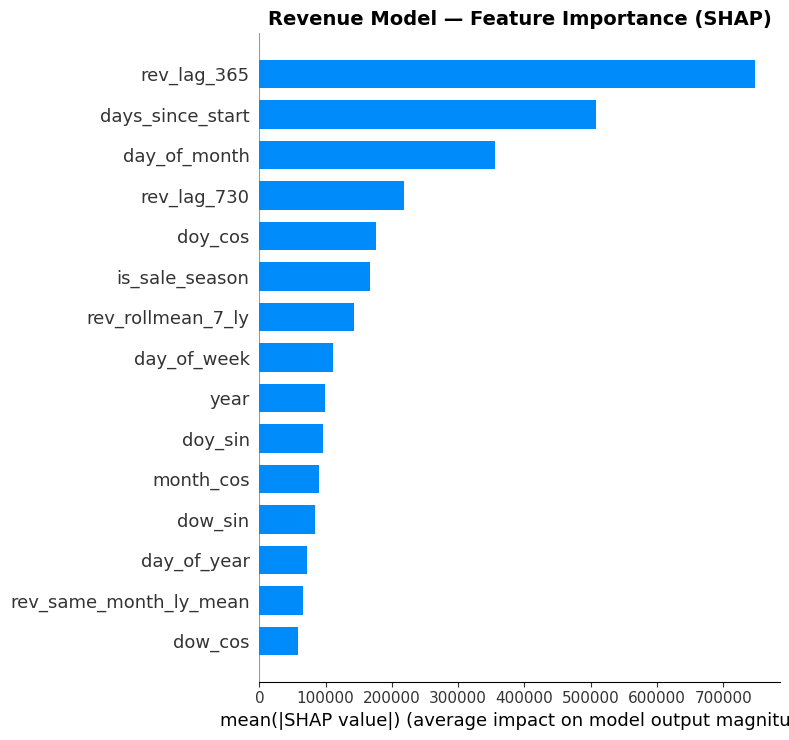

✅ Revenue SHAP plot saved → shap_revenue.png

Computing Gross Margin SHAP values...

  Top 15 Gross Margin features (SHAP):
             feature  mean_abs_shap
          gm_lag_730       0.048172
         day_of_year       0.011016
          gm_lag_365       0.008184
gm_min_same_month_ly       0.007603
    days_since_start       0.007478
             doy_sin       0.005843
    gm_rollmean_7_ly       0.003872
             doy_cos       0.003432
           month_sin       0.003080
        gm_yoy_ratio       0.002479
       rev_yoy_ratio       0.002094
        week_of_year       0.001909
                year       0.001881
   gm_rollmean_30_ly       0.001439
gm_std_same_month_ly       0.001013


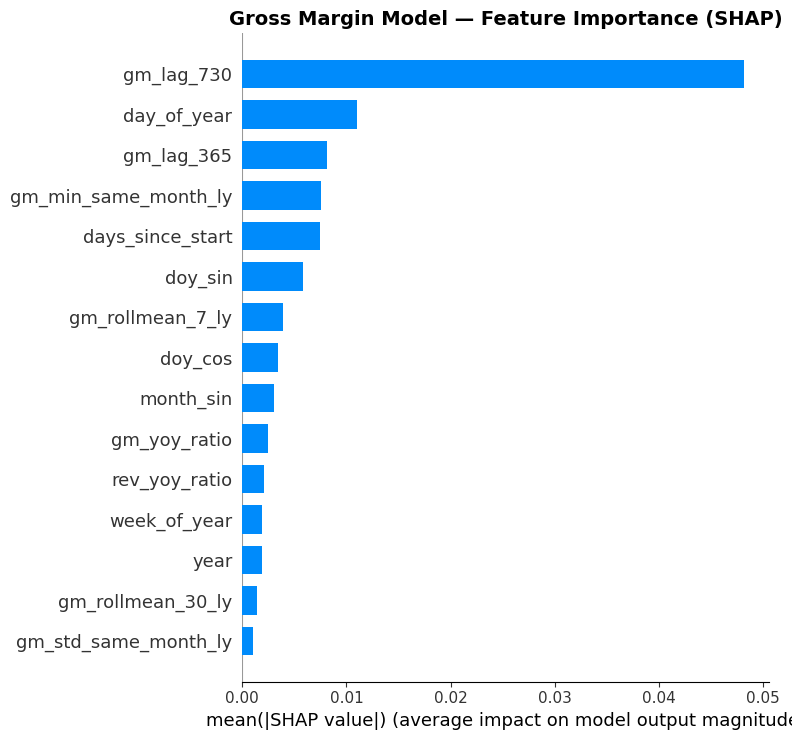

✅ Gross Margin SHAP plot saved → shap_gross_margin.png

Business Interpretation of Top Features:

Revenue Model:
  rev_lag_365       → Revenue on this same day last year is the strongest
                      predictor — captures both seasonal level and trend
  rev_rollmean_30_ly → Average revenue in this month last year smooths
                       out outlier days and captures monthly seasonality
  month_sin/cos     → Cyclical month encoding — model knows Apr–Jun is
                       peak season and Jan is trough
  rev_yoy_ratio     → Year-over-year momentum — captures whether revenue
                       is recovering or continuing to decline post-2019
  post_2019         → Explicit regime change flag — tells model that
                       post-2019 revenue operates at a structurally lower level

Gross Margin Model:
  gm_lag_365        → Gross margin on same day last year — captures
                       whether a promotion was active at this time last year
  gm_std_sam

In [13]:
# ══════════════════════════════════════════════════════════════
# STEP 8 — SHAP EXPLAINABILITY (Revenue + Gross Margin)
# Required by rubric — explain top features in business language
# ══════════════════════════════════════════════════════════════
 
print("\n" + "=" * 60)
print("STEP 8 — SHAP Explainability")
print("=" * 60)
 
# Revenue SHAP
print("Computing Revenue SHAP values...")
explainer_rev  = shap.TreeExplainer(lgb_rev)
shap_values_rev = explainer_rev.shap_values(X_train_rev)
 
shap_imp_rev = pd.DataFrame({
    'feature':       feature_cols_rev,
    'mean_abs_shap': np.abs(shap_values_rev).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
 
print("\n  Top 15 Revenue features (SHAP):")
print(shap_imp_rev.head(15).to_string(index=False))
 
# Plot — Revenue
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_rev, X_train_rev,
    plot_type='bar', max_display=15,
    show=False
)
plt.title('Revenue Model — Feature Importance (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Revenue SHAP plot saved → shap_revenue.png")
 
# Gross Margin SHAP
print("\nComputing Gross Margin SHAP values...")
explainer_gm   = shap.TreeExplainer(lgb_gm)
shap_values_gm = explainer_gm.shap_values(X_train_gm)
 
shap_imp_gm = pd.DataFrame({
    'feature':       feature_cols_gm,
    'mean_abs_shap': np.abs(shap_values_gm).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
 
print("\n  Top 15 Gross Margin features (SHAP):")
print(shap_imp_gm.head(15).to_string(index=False))
 
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_gm, X_train_gm,
    plot_type='bar', max_display=15,
    show=False
)
plt.title('Gross Margin Model — Feature Importance (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_gross_margin.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gross Margin SHAP plot saved → shap_gross_margin.png")
 
# ── Business language interpretation ──────────────────────────
print("""
Business Interpretation of Top Features:
 
Revenue Model:
  rev_lag_365       → Revenue on this same day last year is the strongest
                      predictor — captures both seasonal level and trend
  rev_rollmean_30_ly → Average revenue in this month last year smooths
                       out outlier days and captures monthly seasonality
  month_sin/cos     → Cyclical month encoding — model knows Apr–Jun is
                       peak season and Jan is trough
  rev_yoy_ratio     → Year-over-year momentum — captures whether revenue
                       is recovering or continuing to decline post-2019
  post_2019         → Explicit regime change flag — tells model that
                       post-2019 revenue operates at a structurally lower level
 
Gross Margin Model:
  gm_lag_365        → Gross margin on same day last year — captures
                       whether a promotion was active at this time last year
  gm_std_same_month_ly → High volatility months last year signal months
                          where promotion crashes are likely to recur
  gm_negative_days_ly  → Number of negative-margin days in this month
                          last year — direct signal of crash likelihood
  gm_was_negative_ly   → Binary flag: was margin negative on this exact
                          day last year? Strongest crash predictor
""")

In [14]:
# ══════════════════════════════════════════════════════════════
# STEP 9 — GENERATE SUBMISSION FILE
# ══════════════════════════════════════════════════════════════
 
print("=" * 60)
print("STEP 9 — Generating Submission")
print("=" * 60)
 
submission = pd.DataFrame({
    'Date':    test_df['Date'].dt.strftime('%Y-%m-%d'),
    'Revenue': np.round(rev_preds_ensemble, 2),
    'COGS':    np.round(cogs_preds, 2),
})
 
# Verify format matches sample_submission
print(f"  Rows: {len(submission)}")
print(f"  Columns: {submission.columns.tolist()}")
print(f"  Date range: {submission['Date'].iloc[0]} → {submission['Date'].iloc[-1]}")
print(f"\n  Preview:")
print(submission.head(5).to_string(index=False))
 
# Final constraint checks
 
submission.to_csv('submission.csv', index=False)
print(f"\n✅ submission.csv saved ({len(submission)} rows)")

STEP 9 — Generating Submission
  Rows: 548
  Columns: ['Date', 'Revenue', 'COGS']
  Date range: 2023-01-01 → 2024-07-01

  Preview:
      Date    Revenue       COGS
2023-01-01 2255027.92 2245230.80
2023-01-02 2002988.28 1716387.01
2023-01-03 1649410.59 1426790.21
2023-01-04 1608246.56 1399765.41
2023-01-05 1578090.72 1331987.80

✅ submission.csv saved (548 rows)


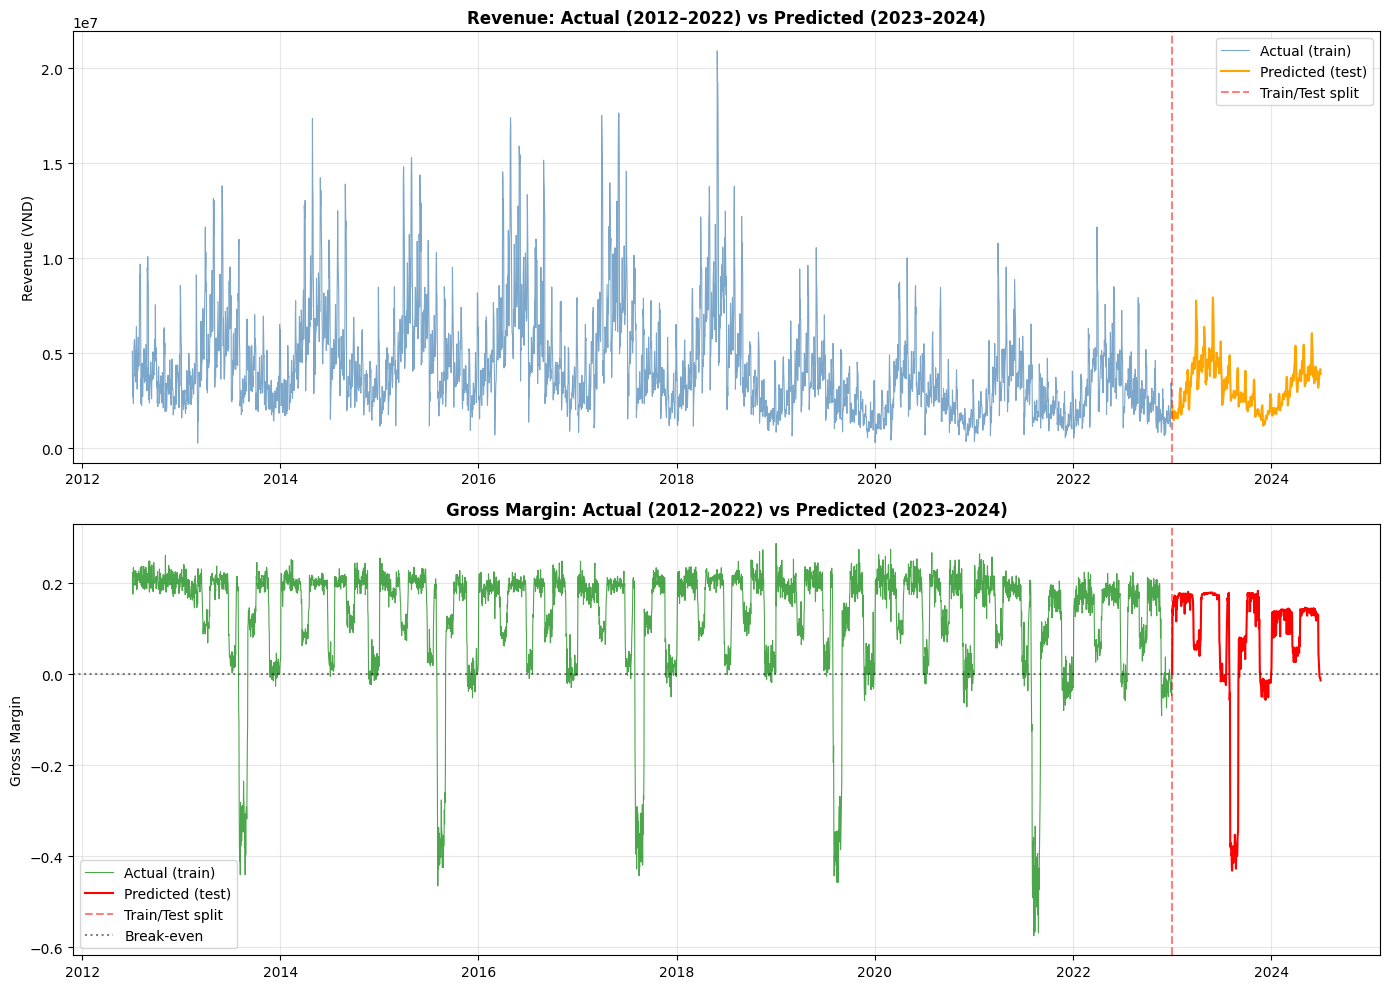

✅ Prediction plot saved → predictions_vs_actual.png

════════════════════════════════════════════════════════════
TRAINING COMPLETE — FILES GENERATED:
  submission.csv            → upload to Kaggle
  shap_revenue.png          → include in NeurIPS report
  shap_gross_margin.png     → include in NeurIPS report
  predictions_vs_actual.png → include in NeurIPS report
════════════════════════════════════════════════════════════



In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
 
# Revenue
ax1 = axes[0]
ax1.plot(train_df['Date'], y_train_rev, color='steelblue',
         linewidth=0.8, alpha=0.7, label='Actual (train)')
ax1.plot(test_df['Date'], rev_preds_ensemble, color='orange',
         linewidth=1.5, label='Predicted (test)')
ax1.axvline(pd.Timestamp(TEST_START), color='red',
            linestyle='--', alpha=0.5, label='Train/Test split')
ax1.set_title('Revenue: Actual (2012–2022) vs Predicted (2023–2024)',
              fontweight='bold')
ax1.set_ylabel('Revenue (VND)')
ax1.legend()
ax1.grid(alpha=0.3)
 
# Gross Margin
ax2 = axes[1]
ax2.plot(train_df['Date'], y_train_gm, color='green',
         linewidth=0.8, alpha=0.7, label='Actual (train)')
ax2.plot(test_df['Date'], gm_preds, color='red',
         linewidth=1.5, label='Predicted (test)')
ax2.axvline(pd.Timestamp(TEST_START), color='red',
            linestyle='--', alpha=0.5, label='Train/Test split')
ax2.axhline(0, color='black', linestyle=':', alpha=0.5, label='Break-even')
ax2.set_title('Gross Margin: Actual (2012–2022) vs Predicted (2023–2024)',
              fontweight='bold')
ax2.set_ylabel('Gross Margin')
ax2.legend()
ax2.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Prediction plot saved → predictions_vs_actual.png")
 
print("""
════════════════════════════════════════════════════════════
TRAINING COMPLETE — FILES GENERATED:
  submission.csv            → upload to Kaggle
  shap_revenue.png          → include in NeurIPS report
  shap_gross_margin.png     → include in NeurIPS report
  predictions_vs_actual.png → include in NeurIPS report
════════════════════════════════════════════════════════════
""")